Il test abbastanza semplice a cui abbiamo pensato è quello della moneta truccata. In sostanza durante questo test io ho la possibilità di lanciare una moneta e così facendo devo capire se posso accettare l'ipotesi di lavoro $H_0$ per cui la moneta è truccata oppure se devo riggettarla a favore dell'ipotesi $H_1$ secondo cui la moneta è truccata.

Nell'ipotesi di lavoro posso prendere come parametro la probabilità che esca testa $p(testa)$ e porla uguale a quella che esca croce, che poi sarà uguale ad 1/2 $\Rightarrow p(testa)=p(croce)=0.5$. 

Definisco poi un'ipotesi alternativa $H_1$ secondo cui $p(croce)>p(testa)$ per effettuare un test di ipotesi ad una coda. Mentre l'ipotesi $H_0$ è un'ipotesi semplice, l'ipotesi $H_1$ è composita. 

Supponiamo allora di effettuare un numero $n=10$ di lanci e di ottenere $k=7$ volte croce. In questo caso scegliamo come statistica proprio il numero di volte in cui è stata osservata croce (ovvero i successi). Il processo è chiaramente binomiale. Supponiamo inoltre di vole effettuare un test al $90 \%$ di confidenza e di consguenza devo prendere $\alpha =0.1$. 

La prima cosa che devo fare è determinare il valore di soglia che divide la regione di accettazione da quella di rifiuto. Iniziamo subito a vedere come è fatto la pdf binomiale che regola il numero di successi $k$ su queste 10 "estrazioni" effettuate quando la probabilità di successo $p=0.5$, quindi ci vediamo la pdf della statistica scelta sotto l'ipotesi $H_0$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom
from IPython.display import display, Math

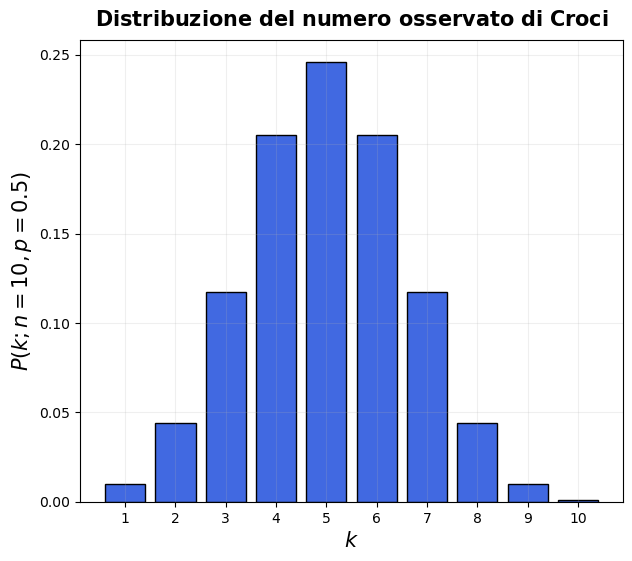

In [23]:
k=7
n=10
p=0.5

ks = [n for n in range(1,n+1)]
ys = [binom.pmf(k,n,p) for k in ks]

fig,ax = plt.subplots(figsize=(7,6))
ax.bar(ks,ys,color='royalblue', edgecolor='black')
ax.set_xticks(ks)
ax.set_xlabel(r'$\mathit{k}$', fontsize = 15)
ax.set_ylabel(r'$\mathit{P(k;n=10,p=0.5)}$', fontsize = 15)
ax.set_title(r'$\mathbf{Distribuzione\ del\ numero\ osservato\ di\ Croci}$', pad=10,fontsize = 15)
plt.grid(True,alpha=0.2)
plt.show()

Tutte le ipotesi $H_1' \in H_1$ sono tutte più grandi. Possiamo ad esempio pensare di campionarle come $p(croce)=0.55$, poi $p(croce)=0.6$, poi $p(croce)=0.65$ ecc... e questo produce l'effetto che a mano a mano la pdf associata alla statistica k sotto ipotesi $H_1$ si sposta verso destra. Lo mostriamo di seguito:

In [2]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, Image, display
def confronto_pdf(video=True, fotogrammi=False):
    if video:                
        k = 7
        n = 10
        p = 0.5

        ks = np.arange(0, n+1)
        ys = binom.pmf(ks, n, p)

        ps_H1 = np.linspace(0.55, 0.95, 80)

        fig, ax = plt.subplots(figsize=(7,6))

        def update(i):
            ax.clear()
            
            p_H1 = ps_H1[i]
            ys_H1 = binom.pmf(ks, n, p_H1)
            
            ax.bar(ks, ys, color='royalblue', edgecolor='black',
                label=r"$H_0:\ p=0.5$")
            
            ax.bar(ks, ys_H1, color='hotpink', edgecolor='black',
                label=rf"$H_1':\ p={p_H1:.2f}$")
            
            ax.set_xlim(0, 12)
            ax.set_ylim(0, 0.45)
            ax.set_xticks(np.arange(0, 13, 1))
            
            ax.set_xlabel(r'$\mathit{k}$', fontsize=15)
            ax.set_ylabel(r'$\mathit{P(k;n=10,p)}$', fontsize=15)
            
            ax.set_title(
                r"$\mathbf{Confronto\ delle\ pdf\ al\ variare\ di\ H_1'}$",
                pad=10,
                fontsize=15
            )
            
            ax.grid(True, alpha=0.2)
            ax.legend(fontsize=12, loc='upper left')

        anim = FuncAnimation(

            fig,

            update,

            frames=len(ps_H1),

            interval=30,

            repeat=True

        )

        plt.close(fig)

        display(HTML(anim.to_jshtml()))

        return
    

    if fotogrammi:
        k=7
        n=10
        p=0.5

        ks = [n for n in range(1,n+1)]
        ys = [binom.pmf(k,n,p) for k in ks]

        ps_H1=[0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95]
        for p_H1 in ps_H1:
            ys_H1 = [binom.pmf(k,n,p_H1) for k in ks]
            fig,ax = plt.subplots(figsize=(7,6))
            ax.bar(ks,ys,color='royalblue', edgecolor='black', label=r"$H_0:\ p=0.5$")
            ax.bar(ks,ys_H1,color='hotpink', edgecolor='black',label=rf"$H_1':\ p={p_H1:.2f}$")
            ax.set_xticks(ks)
            ax.set_xlabel(r'$\mathit{k}$', fontsize = 15)
            ax.set_ylabel(r'$\mathit{P(k;n=10,p)}$', fontsize = 15)
            ax.set_title(r"$\mathbf{Confronto\ delle\ pdf\ al\ variare\ di\ H_1'}$", pad=10,fontsize = 15)
            plt.grid(True,alpha=0.2)

confronto_pdf(video=True,fotogrammi=False)  #non può mostrare video e fotogrammi insieme, o l'una o l'altra cosa


Se ora abbiamo scelto di eseguire un test al livello di confidenza del $90\%$, dobbiamo imporre che $\alpha = P(T(X)\in W_1 \mid H_0)$ dove $\alpha=0.1$ rappresenta la probabilità di errore di prima specie, cioè la probabilità di rifiutare $H_0$ quando essa è vera.

La statistica test che abbiamo scelto è il numero di croci osservate, che indichiamo con $n_c$. Sotto l’ipotesi alternativa vale $H_1:\ p(\text{croce})>0.5$ quindi valori grandi di $n_c$ favoriscono l’ipotesi alternativa. Per questo motivo bisogna individuare una regione critica della forma $W_1=\{n_c\ge \bar n\}$ dove $\bar n$ è una soglia critica da determinare.

La precedente equazione può quindi essere riscritta come $\alpha=P(n_c\ge \bar n \mid H_0)=0.1$. In altre parole, stiamo imponendo che la probabilità di ottenere un numero di croci sufficientemente grande da farci rifiutare $H_0$, quando in realtà $H_0$ è vera, sia pari a $0.1$.

Per determinare la soglia $\bar n$, dobbiamo lavorare sotto l’ipotesi nulla $H_0$, cioè assumendo che la distribuzione binomiale sia caratterizzata da $p=p(\text{croce})=0.5$

Possiamo quindi utilizzare la funzione cumulativa della distribuzione binomiale con probabilità di successo $p=0.5$. Indichiamo tale cumulativa con $F_{\text{Binom},\,p=0.5}(\bar n)$. Essa rappresenta la probabilità di ottenere al massimo $\bar n$ croci: $F_{\text{Binom},\,p=0.5}(\bar n)=P(n_c\le \bar n)$

Poiché però nella relazione precedente compare la probabilità complementare, cioè la probabilità di ottenere almeno $\bar n$ croci, possiamo scrivere

$P(n_c\ge \bar n)=1-F_{\text{Binom},\,p=0.5}(\bar n-1)$   (questa vale per una distribuzione discreta)

e quindi otteniamo

$\alpha=P(n_c\ge \bar n \mid H_0)=1-F_{\text{Binom},\,p=0.5}(\bar n-1)=0.1$ 

In [62]:
alpha = 0.1
n=10 #abbiamo fatto 10 estrazioni
p= 0.5

for k in range(n+1):  #con le pdf non posso usare fsolve che cerca un valore reale ma devo ciclare sui k
    prob = 1 - binom.cdf(k-1, n, p)
    if prob <= alpha:
        bar_n = k
        break

display(Math(fr"\text{{Invertendo l'equazione abbiamo determinato un valore di }} \bar n = {bar_n}"))

<IPython.core.display.Math object>

Quindi se osserviamo 8 o più croci, dipo 9 o anche 10, allora rifiuto l'ipotesi $H_0$ e concludo che la moneta è truccata. Viceversa se osservo al massimo 7 croci non posso rifiutare l'ipotesi di lavoro. 

Ora vogliamo provare ad eseguire un test a due code. In questo caso l'ipotesi di lavoro è sempre $H_0=0.5$ però l'ipotesi alternativa diventa $p(croce) \neq 0.5$, quindi in questo caso la moneta potrebbe favorire croce ma potrebbe anche favorire testa.

Nel caso di prima rifiutavamo $H_0$ solo se il numero di croci è troppo alto. Adesso invece rifiutiamo $H_0$ sia se il numero di crociè troppo alto e sia se il numero di croci è troppo basso. Il fatto è che però noi vogliamo sempre eseguire un testo al $90 \%$ di condifenza ma non possiamo più concentrare tutto il valore di $\alpha$ nella coda di destra. Siamo invece costretti a dividere questa probabilità tra due code:

- $\alpha^+=0.05$
- $\alpha^-=0.05$

A questo punto dobbiamo determinare 2 soglie, una superiore ed una inferiore. In questo caso la regione di rigetto dell'ipotesi di lavoro verrà costruita come $W_1={n_c\ge n_{sup}}\cup{n_c\le n_{inf}}$.

Per la determinazione delle due soglie dovremmo come al solito imporre le seguenti:

- $P(n_c\ge m_{sup}\mid H_0)= P(n_c\ge m_{sup})=1-F_{Binom}(n_{sup}-1)=0.05$ (coda superiore)
- $P(n_c\le m_{inf}\mid H_0)= P(n_c\le m_{inf})=F_{Binom}(n_{inf})= 0.05$ (coda inferiore)

In [72]:
alpha = 0.05
n=10 #abbiamo fatto 10 estrazioni
p= 0.5

for k in range(n+1):  #con le pdf non posso usare fsolve che cerca un valore reale ma devo ciclare sui k
    prob_sup= 1 - binom.cdf(k-1, n, p)
    
    if prob_sup <= alpha:
        n_sup= k
        break
    
for k in range(n+1):
    prob_inf=binom.cdf(k, n, p)
    if prob_inf <= alpha:
        n_inf=k
    

display(Math(
    fr"\text{{Invertendo l'equazione abbiamo determinato le due soglie critiche: }}"
    fr"n_{{\mathrm{{inf}}}}={n_inf},\quad "
    fr"n_{{\mathrm{{sup}}}}={n_sup}"
))

<IPython.core.display.Math object>

Quindi accetto l'ipotesi di lavoro in questo caso se mi esce un numero di croci tra 2 ed 8 (inclusi) non posso rifiutare l'ipotesi nulla. Nel test a due code con 8 già potevo rifiutarla.